# EDA — Health Insurance Premium & Risk Analytics

Source: `data/processed/policyholders_clean.csv` (1,337 rows, post-dedup,
feature-engineered in `sql/02_clean_and_transform.sql`).

Goal: understand what actually drives `charges` before building a model on it —
if the model can't be justified by what's in this notebook, it shouldn't ship.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("../data/processed/policyholders_clean.csv")
df.shape


(1337, 11)

In [2]:
df.head()

,age,sex,bmi,children,smoker,region,charges,bmi_category,age_band,risk_tier,region_obesity_benchmark_pct
0,19,female,27.900,0,yes,southwest,16884.92400,overweight,18-24,elevated,34.7
1,18,male,33.770,1,no,southeast,1725.55230,obese,18-24,elevated,34.7
2,28,male,33.000,3,no,southeast,4449.46200,obese,25-34,elevated,34.7
3,33,male,22.705,0,no,northwest,21984.47061,normal,25-34,standard,29.1
4,32,male,28.880,0,no,northwest,3866.85520,overweight,25-34,standard,29.1


In [3]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1337.0,NaN,NaN,NaN,39.222139,14.044333,18.0,27.0,39.0,51.0,64.0
sex,1337,2,male,675,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1337.0,NaN,NaN,NaN,30.663452,6.100468,15.96,26.29,30.4,34.7,53.13
children,1337.0,NaN,NaN,NaN,1.095737,1.205571,0.0,0.0,1.0,2.0,5.0
smoker,1337,2,no,1063,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1337,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,1337.0,NaN,NaN,NaN,13279.121487,12110.359656,1121.8739,4746.344,9386.1613,16657.71745,63770.42801
bmi_category,1337,4,obese,706,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age_band,1337,5,45-54,287,NaN,NaN,NaN,NaN,NaN,NaN,NaN
risk_tier,1337,3,elevated,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1. Distribution of charges

Insurance charges are almost never normally distributed — cost data is
right-skewed because most people are cheap to insure and a small number
of high-severity cases pull the tail. Confirming that shape here because
it directly affects which model/loss function makes sense later
(a linear model on raw charges will be pulled around by the tail;
log-transforming is the standard fix).


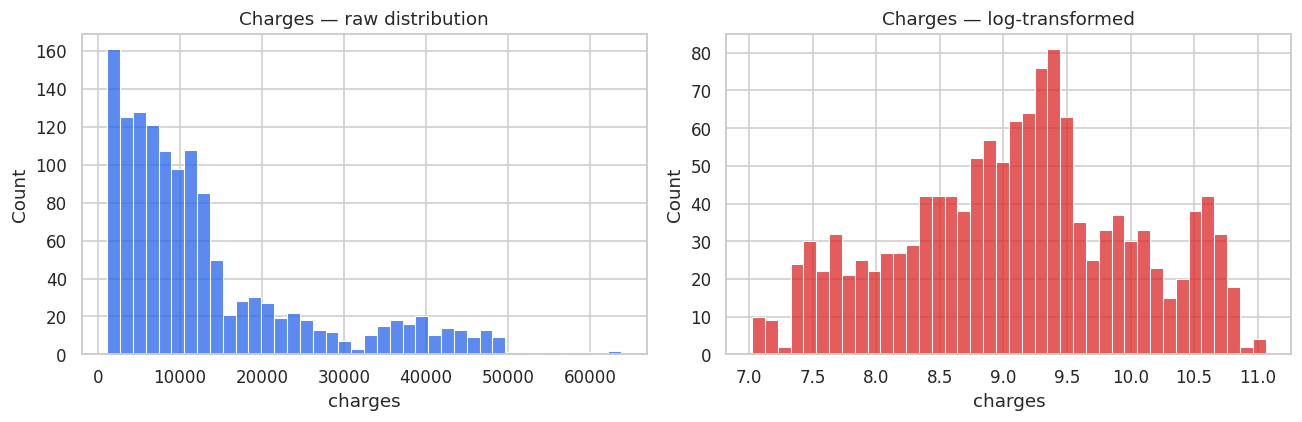

Skewness (raw): 1.52
Skewness (log): -0.09


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["charges"], bins=40, ax=axes[0], color="#2563eb")
axes[0].set_title("Charges — raw distribution")

sns.histplot(np.log1p(df["charges"]), bins=40, ax=axes[1], color="#dc2626")
axes[1].set_title("Charges — log-transformed")
plt.tight_layout()
plt.savefig("../reports/fig_charges_distribution.png", dpi=150)
plt.show()

print("Skewness (raw):", df["charges"].skew().round(2))
print("Skewness (log):", np.log1p(df["charges"]).skew().round(2))


**Finding:** raw charges are heavily right-skewed (skew ≈ 1.5). Log-transform
brings it much closer to symmetric. This dataset needs either a log-target
regression or a tree-based model that doesn't assume normality.

## 2. Smoking status — the dominant cost driver

Smoking is the variable every published analysis of this dataset flags as
the single biggest cost driver. Verifying it directly rather than assuming it.

/tmp/ipykernel_217/3317562006.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="smoker", y="charges", ax=ax, palette={"no": "#94a3b8", "yes": "#dc2626"})


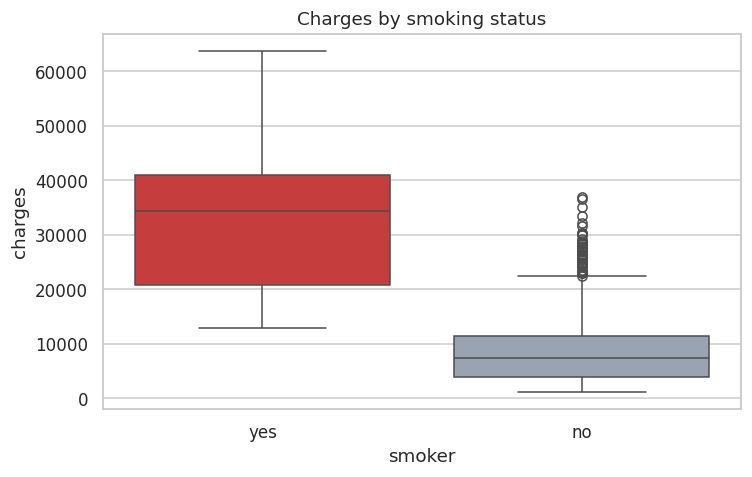

,mean,median,count
smoker,,,
no,8441.0,7346.0,1063
yes,32050.0,34456.0,274


In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(data=df, x="smoker", y="charges", ax=ax, palette={"no": "#94a3b8", "yes": "#dc2626"})
ax.set_title("Charges by smoking status")
plt.tight_layout()
plt.savefig("../reports/fig_charges_by_smoker.png", dpi=150)
plt.show()

df.groupby("smoker")["charges"].agg(["mean", "median", "count"]).round(0)


**Finding:** smokers pay roughly 3.8x the mean charges of non-smokers
(and ~4.7x the median). This isn't a subtle effect — it's the strongest
single signal in the dataset, and any model that doesn't weight it heavily
is under-fit.

## 3. BMI category × smoking — interaction effect

The resume/project framing is "risk analytics," not just "cost prediction" —
that means looking for how risk factors *combine*, not just their marginal
effects. Testing whether obesity compounds the smoking effect.

In [6]:
pivot = df.pivot_table(values="charges", index="bmi_category", columns="smoker", aggfunc="mean").round(0)
pivot = pivot.reindex(["underweight", "normal", "overweight", "obese"])
pivot


smoker,no,yes
bmi_category,,
underweight,5533.0,18810.0
normal,7686.0,19942.0
overweight,8258.0,22496.0
obese,8856.0,41558.0


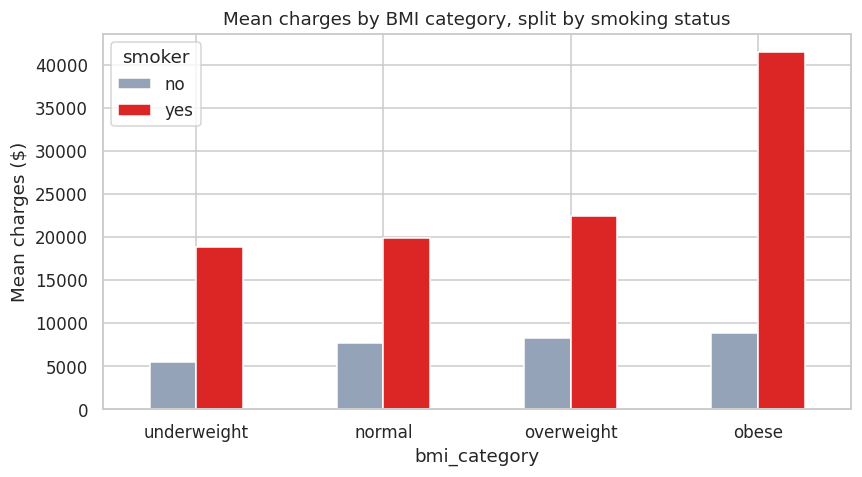

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
pivot.plot(kind="bar", ax=ax, color=["#94a3b8", "#dc2626"])
ax.set_title("Mean charges by BMI category, split by smoking status")
ax.set_ylabel("Mean charges ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../reports/fig_bmi_smoker_interaction.png", dpi=150)
plt.show()


**Finding:** obesity alone raises average charges modestly among non-smokers,
but among smokers, moving from normal BMI to obese roughly doubles average
charges (obese smokers pay ~2.1x what normal-BMI smokers pay). This is a real
interaction effect — obesity and smoking compound each other rather than
adding independently. This justifies the `risk_tier` composite flag built in
the SQL transform step (`high` = smoker AND obese).

## 4. Age vs. charges

Age is expected to correlate with cost (routine actuarial assumption) —
checking the shape and whether smoking changes the slope.

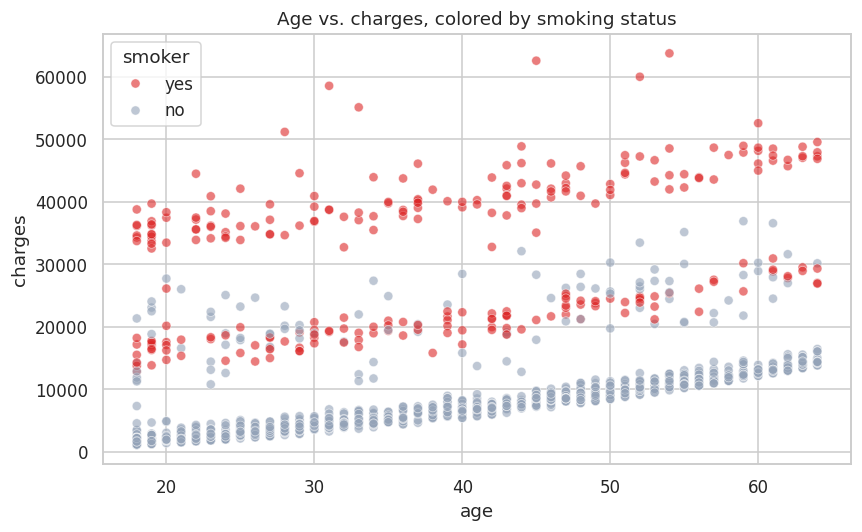

,age,charges
age,1.0,0.3
charges,0.3,1.0


In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x="age", y="charges", hue="smoker", alpha=0.6,
                 palette={"no": "#94a3b8", "yes": "#dc2626"}, ax=ax)
ax.set_title("Age vs. charges, colored by smoking status")
plt.tight_layout()
plt.savefig("../reports/fig_age_vs_charges.png", dpi=150)
plt.show()

df[["age", "charges"]].corr().round(2)


**Finding:** age has a clear positive relationship with charges within each
smoking group — you can see three roughly parallel bands (non-smokers, smokers,
and a higher smoker+high-BMI band) rather than one continuous cloud. The
overall correlation (r≈0.3) understates this because it's measured across the
whole mixed population; within each smoking band the age trend is clearer.
This is a strong signal that an interaction term (age × smoker, or a tree
model that can find this split automatically) will outperform a plain
additive linear model.

## 5. Regional benchmark join — does it add signal?

This is the point of the CDC regional benchmark join: check whether regional
obesity context actually correlates with what we see in this specific
policyholder sample, as a sanity check on the join before trusting it in a model.

In [9]:
region_summary = df.groupby("region").agg(
    avg_charges=("charges", "mean"),
    avg_bmi=("bmi", "mean"),
    pct_smokers=("smoker", lambda s: (s == "yes").mean() * 100),
    cdc_obesity_benchmark=("region_obesity_benchmark_pct", "first"),
).round(2).sort_values("avg_charges", ascending=False)
region_summary


,avg_charges,avg_bmi,pct_smokers,cdc_obesity_benchmark
region,,,,
southeast,14735.41,33.36,25.00,34.7
northeast,13406.38,29.17,20.68,28.6
northwest,12450.84,29.20,17.90,29.1
southwest,12346.94,30.60,17.85,34.7


**Finding:** the sample's own average BMI by region loosely tracks the CDC
regional benchmark direction (southeast/southwest show both higher sample BMI
and a higher CDC benchmark than northeast), though this is a small sample
(~330 people per region) so it's directional context, not a statistically
independent confirmation. It's used downstream as a contextual feature, not
a substitute for the individual's own BMI.

## 6. Risk tier validation

Confirming the `risk_tier` field built in SQL actually separates charges
the way it's intended to before using it anywhere downstream.

/tmp/ipykernel_217/4180672751.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="risk_tier", y="charges", order=order, ax=ax, palette="Reds")


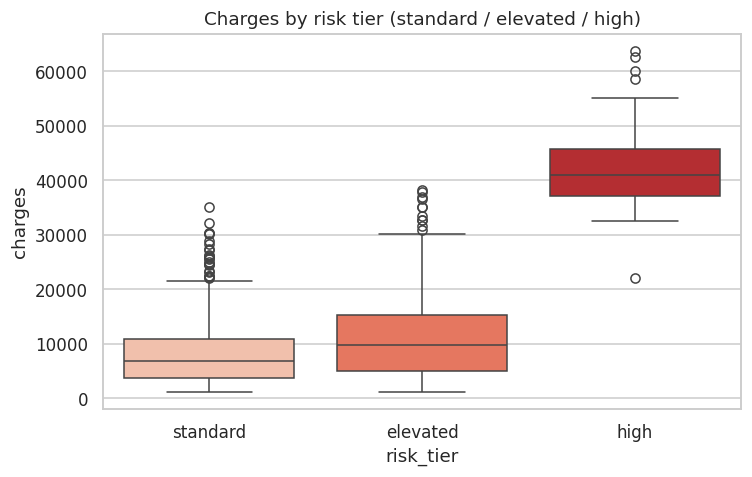

,mean,median,count
risk_tier,,,
standard,7977.0,6762.0,502
elevated,11194.0,9826.0,690
high,41558.0,40904.0,145


In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5))
order = ["standard", "elevated", "high"]
sns.boxplot(data=df, x="risk_tier", y="charges", order=order, ax=ax, palette="Reds")
ax.set_title("Charges by risk tier (standard / elevated / high)")
plt.tight_layout()
plt.savefig("../reports/fig_risk_tier_validation.png", dpi=150)
plt.show()

df.groupby("risk_tier")["charges"].agg(["mean", "median", "count"]).reindex(order).round(0)


**Finding:** the three-tier risk flag cleanly separates charges — `high`
policyholders (smoker + obese) average roughly 5.2x the `standard` tier. This
validates the composite flag as a usable segmentation for the risk analytics
side of the platform, independent of the regression model.

## Summary of EDA findings

1. Charges are right-skewed → log-transform or tree-based model for prediction.
2. Smoking status is the dominant single driver (~3.8x mean cost multiplier).
3. Smoking × obesity is a real interaction effect, not additive — justifies
   the composite `risk_tier` field.
4. Age correlates with charges within each smoking band; interaction terms
   or a tree model should outperform a plain linear model.
5. Regional CDC benchmark join is directionally consistent with the sample
   but should be treated as contextual, not a primary predictor.
6. `risk_tier` cleanly separates charge distributions (~5.2x high vs standard)
   — usable as-is for segmentation in the dashboard even before the
   regression model is built.

Next: `src/train_model.py` — regression model for `charges`, using smoker,
BMI, age, and their interactions as the core features identified here.
